#### Buid A Basic ChatBot With LangGraph (Graph API)

In [141]:
## import required libs
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



In [142]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the Annotation defines how this state key should be updated
    # (in this case, it append messages to the list, rather thn over writting them)
    messages:Annotated[list,add_messages]



In [143]:
# import Environment related lib to load KEYS
import os
from dotenv import load_dotenv
# Load Env KEYS and values
load_dotenv()

True

In [144]:
# import generic chat models
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="qwen/qwen3-32b",
    model_provider="groq"
) # Groq model

In [145]:
# Node functionality
def chatBot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

In [146]:
Graph_Builder = StateGraph(State)
## Add node
Graph_Builder.add_node("groqChatBot",chatBot) 
## Add Edge
Graph_Builder.add_edge(START,"groqChatBot")
Graph_Builder.add_edge("groqChatBot",END)

## Compile the Graph
graph = Graph_Builder.compile()

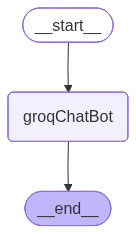

In [147]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [148]:
response = graph.invoke({"messages":"Hi"})

In [149]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". I should respond in a friendly and welcoming way. Maybe ask how I can assist them. Keep it open-ended so they can specify what they need help with. Make sure the tone is positive and approachable. Let me put that together.\n</think>\n\nHello! How can I assist you today? 😊'

In [150]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user is asking "Hi how are you?" which is a common greeting. I need to respond politely and show that I'm here to help. I should acknowledge their greeting and let them know I'm ready to assist with any questions they might have. Keep it friendly and open-ended. Maybe add an emoji to keep the tone casual. Let me check if there's any specific way they want the response formatted. No, just a natural, conversational reply. Alright, time to put that together.
</think>

I'm doing well, thanks for asking! 😊 How can I assist you today?


### ChatBot With Tools

In [151]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. * Organises AI agent workflows using graph-based architectures. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step 

In [152]:
## Custom functions
def multiply(a:int,b:int)-> int:
    """Multiply a and b

    Args:
        a (int): First int number
        b (int): Second int number

    Returns:
        int: result in int
    """
    return a*b

def sum(a:int,b:int)-> int:
    """Sum two integer numbers

    Args:
        a (int): First integer number
        b (int): Second Integer Number

    Returns:
        int: Sum of two number
    """
    return a+b

In [153]:
tools=[tool,multiply,sum]

In [154]:
model_with_tools = model.bind_tools(tools)
model_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1150e4510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1150e5810>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurat

In [155]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

graph = builder.compile()

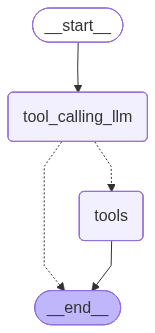

In [156]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [157]:
response = graph.invoke({"messages":"What is recent AI news"})

In [158]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79293, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "The last three days have been a nonstop parade of new products, features, and frontier model releases from the leading AI labs. There are new names like \\"Sol\\" and \\"Terra,\\" as well as new features for image creation and voice assistants. Microsoft added a splash of weird with its \\"poetry pharmacy.\\"\\n\\nThere were also major personnel changes. First, OpenAI\'s chief futurist left after nine years. Then OpenAI\'s CEO of appplications, Fidji Simo, stepped down after her medical leave.\\n\\nBehind the scenes, Perplexity is quietly working on a new coding tool called \\"Teammate\\" to compete with Anthropic and OpenAI, Business In

In [159]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (g7k2mn74r)
 Call ID: g7k2mn74r
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79293, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "The last three days have been a nonstop parade of new products, features, and frontier model releases from the leading AI labs. There are new names like \"Sol\" and \"Terra,\" as well as new features 

In [160]:
response = graph.invoke({"messages":"What is 2 multiplied by 2 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 2 ?
================================== Ai Message ==================================
Tool Calls:
  multiply (dn4avkcvx)
 Call ID: dn4avkcvx
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [161]:
response = graph.invoke({"messages":"What is 2 multiplied by 5 and multiply by 6 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and multiply by 6 ?
================================== Ai Message ==================================
Tool Calls:
  multiply (zzkbn7rn9)
 Call ID: zzkbn7rn9
  Args:
    a: 2
    b: 5
  multiply (6z6fgmfc6)
 Call ID: 6z6fgmfc6
  Args:
    a: 10
    b: 6
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

60


In [162]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (cka9qxxm9)
 Call ID: cka9qxxm9
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
  multiply (sncqttfhg)
 Call ID: sncqttfhg
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.prnewswire.com/news-releases/latest-news-topics/artificial-intelligence", "title": "Artificial Intelligence News & Press Releases from PR Newswire", "content": "## View All Travel\n\n## Policy & Public Interest\n\n## Policy & Public Interest Overview\n\n## View All Policy & Public Interest\n\n## People & Culture\n\n## People & Culture Overview\n\n## V

In [163]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 ?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (q5m3wx09a)
 Call ID: q5m3wx09a
  Args:
    query: AI news
    time_range: week
  multiply (aea05dtwv)
 Call ID: aea05dtwv
  Args:
    a: 5
    b: 6
  multiply (rmrxy3sjp)
 Call ID: rmrxy3sjp
  Args:
    a: 30
    b: 8
================================= Tool Message =================================
Name: tavily_search

No search results found for 'AI news'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches.
================================= Tool Message =================================
Name: multiply

30
================================= Tool Message =================================
Name: multiply

240


In [164]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?
================================== Ai Message ==================================


### REACT Agent Architecture

In [165]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm") ## Change END -> with tool_calling_llm

graph = builder.compile()

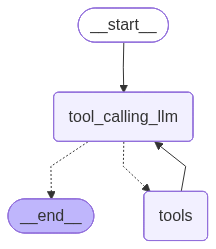

In [166]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [167]:
response = graph.invoke({"messages":"Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent AI news and then multiplied 5 by 6 and again multiply by 8 and add with 15?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (y8dh8arjf)
 Call ID: y8dh8arjf
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (pkfewn8a0)
 Call ID: pkfewn8a0
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/new-ai-model-announcements-openai-meta-grok-2026-7", "title": "The Whirlwind 72 Hours of Rival AI Announcements - Business Insider", "score": 0.79958355, "published_date": "Fri, 10 Jul 2026 15:24:46 GMT", "content": "If we're having trouble keeping up with all the AI news this week, we can't imagine how 

### Adding Memory to Agentic Graph

In [168]:
response = graph.invoke({"messages":"Hello My Name is Giresh Singh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello My Name is Giresh Singh
================================== Ai Message ==================================

Hello, Giresh Singh! How can I assist you today?


In [169]:
response = graph.invoke({"messages":"What is my name?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have access to personal information about users. If you'd like help finding your name or other personal details, you might want to check official records, contact your service provider, or provide more context about what you're trying to find. Would you like help with anything else?


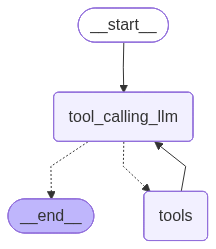

In [170]:
## StateGraph
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver ## this facilate graph to memorize conversations

## initialize memory saver
memory = MemorySaver()

## Node Definition
def tool_calling_llm(state:State):
    return{
            "messages":[model_with_tools.invoke(state["messages"])]
           }

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call -> tools_condition routes to tool
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools","tool_calling_llm") ## Change END -> with tool_calling_llm

graph = builder.compile(checkpointer=memory) ## While compling we will add Memory checkpoin

from IPython.display import display,Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [171]:
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"1"}}
## invoke graph
response = graph.invoke({"messages":"My Name is Giresh Singh"},config=config)
response

{'messages': [HumanMessage(content='My Name is Giresh Singh', additional_kwargs={}, response_metadata={}, id='3640df80-e964-4100-a777-4951dc74bc3c'),
  AIMessage(content='Hello, Giresh Singh! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know!', additional_kwargs={'reasoning_content': "Okay, the user introduced themselves as Giresh Singh. I need to respond appropriately. Since there's no specific query here that requires using the tools provided, my best bet is to acknowledge their introduction and offer assistance. Let me check the tools again to make sure I'm not missing something. The available functions are tavily_search, multiply, and sum. None of these seem relevant for a simple name introduction. So, I'll proceed with a friendly response to prompt them to ask a question or provide more context if needed.\n"}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 1870, 'total_tokens': 2012, 

In [172]:
response['messages'][-1].content

'Hello, Giresh Singh! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know!'

In [173]:
response = graph.invoke({"messages":"What is My Name ?"},config=config)
print(response['messages'][-1].content)

Your name is **Giresh Singh**. You provided it in your previous message. Let me know if there's anything else I can help with! 😊


In [174]:
response = graph.invoke({"messages":"Do you remember My Name ?"},config=config)
print(response['messages'][-1].content)

Yes, your name is **Giresh Singh**! You mentioned it earlier. How can I assist you today, Giresh? 😊


### Streaming
 Without streaming:   
   Start.                                                     
   │
Node A
   │
Node B
   │
Node C
   │
Return Final Result

With streaming:
Start
   │
Node A  ───► Update
   │
Node B  ───► Update
   │
Node C  ───► Update
   │
Final Result

##### Main Streaming Methods
 1. graph.stream(), 2. graph.astream()

##### Streaming Modes
1. stream_mode="values", 2. stream_mode="updates", 3. stream_mode="messages", 4. stream_mode="debug"


In [175]:
from langgraph.checkpoint.memory import MemorySaver ## this facilate graph to memorize conversations

## initialize memory saver
memory = MemorySaver()


In [176]:
## Create a node definition
def superbot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

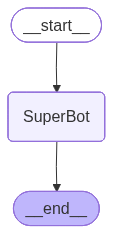

In [177]:
## Create Graph
graph=StateGraph(State)

## Add Node 
graph.add_node("SuperBot",superbot)

## Add Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

## Compile Graph
graph_builder = graph.compile(checkpointer=memory)

## Display Graph
from IPython.display import display,Image
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [178]:
## Invoke Graph
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"1"}}
## invoke graph
response = graph_builder.invoke({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config)
response

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='cf36e739-1a78-4662-838f-f73b080b756e'),
  AIMessage(content="<think>\nOkay, the user introduced himself as Giresh Singh and mentioned he likes to play cricket. I need to respond in a friendly and engaging way. First, I should acknowledge his name and his interest in cricket. Maybe ask him about his role in the game, like if he's a batsman, bowler, or fielder. That shows I'm interested in his passion. Also, asking about his favorite team or any memorable matches could keep the conversation going. I should make sure to use emojis to keep it light and positive. Let me check for any typos and ensure the tone is approachable.\n</think>\n\nHello, Giresh Singh! 🏏 It's great to meet you. Cricket is an amazing sport—I’d love to hear more about your favorite part of playing it! Do you enjoy batting, bowling, or fielding the most? Also, do you have a favorite cr

In [179]:
## Using Stream with update method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"2"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Giresh Singh and he mentioned he likes to play cricket. I need to respond appropriately. First, I should acknowledge his name and his interest. Maybe ask how he got into cricket or what position he plays. Also, check if he plays regularly or just casually. Maybe he's looking to connect with others who play. I should keep the tone friendly and engaging. Let me make sure to invite him to share more about his experience with cricket. Maybe mention some popular players or aspects of the game to keep the conversation flowing. Avoid making assumptions but provide a welcoming response.\n</think>\n\nHi Giresh Singh! Nice to meet you. 🏏 Cricket is such an exciting sport—do you play it casually with friends or are you part of a team? I'd love to hear how you got into it and what you enjoy most about playing! Whether it's batting, bowling, or fielding, every role adds to the fun. Do you have a favorite cricket moment or play

In [180]:
## Using Stream with values method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"2"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='9a7b6fc9-88bc-488b-aefe-85e9037ba949'), AIMessage(content="<think>\nOkay, the user is Giresh Singh and he mentioned he likes to play cricket. I need to respond appropriately. First, I should acknowledge his name and his interest. Maybe ask how he got into cricket or what position he plays. Also, check if he plays regularly or just casually. Maybe he's looking to connect with others who play. I should keep the tone friendly and engaging. Let me make sure to invite him to share more about his experience with cricket. Maybe mention some popular players or aspects of the game to keep the conversation flowing. Avoid making assumptions but provide a welcoming response.\n</think>\n\nHi Giresh Singh! Nice to meet you. 🏏 Cricket is such an exciting sport—do you play it casually with friends or are you part of a team? I'd love to hear how you got into it and wh

In [181]:
## Using Stream with values method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"3"}}
## invoke graph
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Giresh Singh and he likes to play cricket. I should respond in a friendly and engaging way. Let me start by acknowledging his name and his interest.\n\nFirst, I'll greet him and mention that I'm glad to meet him. Then, I should ask him something related to cricket to keep the conversation going. Maybe ask about his favorite team or position if he plays. That way, he can share more and we can talk further.\n\nI need to make sure the questions are open-ended so he has room to elaborate. Also, keeping the tone positive and encouraging is important. Avoid any technical jargon so it's easy for him to respond. Let me check if there's anything else to consider. Oh, maybe add a friendly emoji to make it more approachable. Yeah, that should work.\n</think>\n\nHello Giresh Singh! 🏏 It's great to meet you! Cricket is such an amazing sport—do you play any specific position, or are you a fan of a particular team? I'd love to h

In [182]:
for chunk in graph_builder.stream({"messages":"My Name is Giresh Singh and I also like to play Football"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='074d3d5b-5319-4d46-b2ff-d881ee64464a'), AIMessage(content="<think>\nOkay, the user is Giresh Singh and he likes to play cricket. I should respond in a friendly and engaging way. Let me start by acknowledging his name and his interest.\n\nFirst, I'll greet him and mention that I'm glad to meet him. Then, I should ask him something related to cricket to keep the conversation going. Maybe ask about his favorite team or position if he plays. That way, he can share more and we can talk further.\n\nI need to make sure the questions are open-ended so he has room to elaborate. Also, keeping the tone positive and encouraging is important. Avoid any technical jargon so it's easy for him to respond. Let me check if there's anything else to consider. Oh, maybe add a friendly emoji to make it more approachable. Yeah, that should work.\n</think>\n\nHello Giresh Sin

In [183]:
## Using astream method
## Create Config and then give thread id for each conversation to add in memory
config =  {"configurable":{"thread_id":"4"}}
## invoke graph
async for chunk in graph_builder.astream_events({"messages":"My Name is Giresh Singh and I like to play Cricket"},config=config,version="v2"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'My Name is Giresh Singh and I like to play Cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019f5116-6cdc-77e1-b388-4f0b75969f3e', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='My Name is Giresh Singh and I like to play Cricket', additional_kwargs={}, response_metadata={}, id='5fe53ac5-54fe-4f69-b4fb-78f73bf4ce73')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019f5116-6ce1-7bc0-b917-c2fe2bb84119', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:6c3a97ef-41c8-5c11-7650-ea8db1c0ea90'}, 'parent_ids': ['019f5116-6cdc-77e1-b388-4f0b75969f3e']}
{'event': 'on_chat_model_start', 'data': {'input': {'mess

### Human In Loop

In [184]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model(
    model="qwen/qwen3-32b",
    model_provider="groq"
) # Groq model

llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1150e6650>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1150e6b10>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [191]:
## imports
from typing import Annotated
from typing_extensions import TypedDict
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver ## this facilate graph to memorize conversations

from langgraph.types import Command,interrupt

## initialize memory saver
memory = MemorySaver()

class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

@tool
def human_assistance(query:str) -> str:
    """Request assistance from human"""
    human_response = interrupt({"query":query}) 
    return human_response["data"]

tool = TavilySearch(max_results=2)

tools = [tool,human_assistance]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state:State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # We will disable parallel tool calling

    return {"messages":["message"]}

graph_builder.add_node("chatbot",chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")


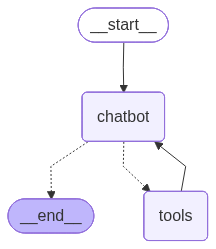

In [186]:
## Compile Graph
graph =graph_builder.compile(checkpointer=memory)

## Display Graph
from IPython.display import display,Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [189]:
user_input = "I need some expert guidance and assistance for building AI Agent. Could you request assistance for me?" 
config = {"configurable":{"thread_id":"7"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()
        

================================ Human Message =================================

I need some expert guidance and assistance for building AI Agent. Could you request assistance for me?
================================ Human Message =================================

message


In [190]:
human_response = (
    "We, the expert here to help ! We would recomond you to check out langgraph to build you Agent"
)

human_command = Command(resume={"data":human_response})

events = graph.stream(
    human_command,
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

message
